In [4]:
# These are our tools - like a kitchen toolkit
import pandas as pd          # for handling data (like Excel in Python)
import numpy as np           # for math operations
import matplotlib.pyplot as plt  # for drawing graphs
import seaborn as sns        # for prettier graphs

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [12]:
import os
import json

os.makedirs('/root/.kaggle', exist_ok=True)

# PUT YOUR USERNAME BELOW 👇
kaggle_config = {
    "username": "SinchananewdvgHS",
    "key": "KGAT_5479c00fb1a887ebeab1535f4c3c05fd"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle setup done!")

✅ Kaggle setup done!


In [13]:
!pip install kaggle -q
!kaggle datasets download -d blastchar/telco-customer-churn
!unzip -o telco-customer-churn.zip

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 72.9MB/s]

Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [14]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("✅ Data loaded!")
print("Shape:", df.shape)
df.head()

✅ Data loaded!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# How many rows and columns?
print("Shape:", df.shape)

# What are the column names?
print("\nColumns:", df.columns.tolist())

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [16]:
# What type of data is in each column?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
# Any empty cells?
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [18]:
# Count how many left vs stayed
print(df['Churn'].value_counts())

# Show as percentage
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


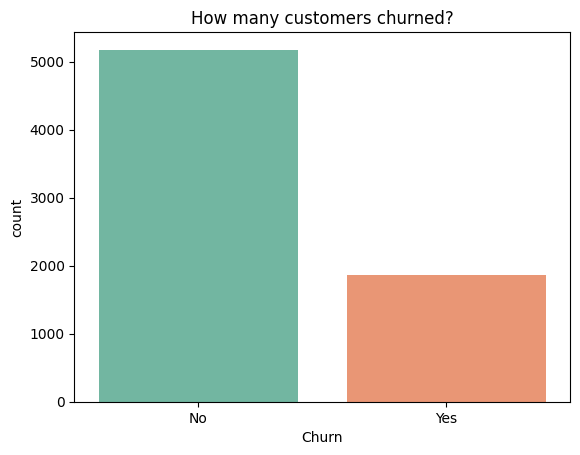

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('How many customers churned?')
plt.show()

In [20]:
# Check the numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [21]:
# TotalCharges should be a number but it is stored as text!
# Let's fix it!
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("✅ TotalCharges fixed!")

✅ TotalCharges fixed!


In [22]:
# Fill empty cells with the average value
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)
print("✅ Missing values filled!")

# Check again - should all be 0 now
print(df.isnull().sum())

✅ Missing values filled!
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [23]:
# customerID is just a random number - not useful for prediction!
df.drop('customerID', axis=1, inplace=True)
print("✅ customerID column removed!")
print("New shape:", df.shape)

✅ customerID column removed!
New shape: (7043, 20)


In [24]:
# Change Yes/No to 1/0 so computer can understand!
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("✅ Churn column fixed!")
print(df['Churn'].value_counts())

✅ Churn column fixed!
Churn
0    5174
1    1869
Name: count, dtype: int64


In [25]:
# Find all text columns
text_columns = df.select_dtypes(include='object').columns
print("Text columns:", text_columns.tolist())

Text columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("✅ All text converted to numbers!")
df.head()

✅ All text converted to numbers!


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [27]:
# X = all columns except Churn (these are the INPUTS)
# y = only Churn column (this is what we PREDICT)

X = df.drop('Churn', axis=1)
y = df['Churn']

print("✅ Split done!")
print("X shape:", X.shape)
print("y shape:", y.shape)

✅ Split done!
X shape: (7043, 19)
y shape: (7043,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # so we get same results every time
)

print("✅ Train/Test split done!")
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

✅ Train/Test split done!
Training rows: 5634
Testing rows: 1409


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Scaling done!")

✅ Scaling done!


In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [31]:
y_pred = model.predict(X_test)

print("✅ Predictions done!")
print("First 10 predictions:", y_pred[:10])
print("First 10 actual:     ", list(y_test[:10]))

✅ Predictions done!
First 10 predictions: [1 0 0 1 0 0 0 0 0 0]
First 10 actual:      [1, 0, 0, 1, 0, 1, 0, 0, 1, 1]


In [32]:
#check accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("✅ Accuracy:", round(accuracy * 100, 2), "%")

✅ Accuracy: 81.62 %


In [33]:
#Detailed Report:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



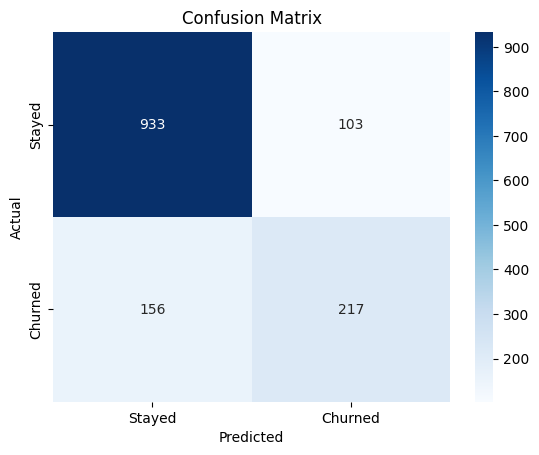

In [34]:
#Confusion Matrix:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [35]:
#improve it with a better model!
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("✅ Random Forest Accuracy:",
      round(accuracy_score(y_test, rf_pred) * 100, 2), "%")

✅ Random Forest Accuracy: 79.35 %


In [36]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("✅ XGBoost Accuracy:",
      round(accuracy_score(y_test, xgb_pred) * 100, 2), "%")

✅ XGBoost Accuracy: 78.14 %


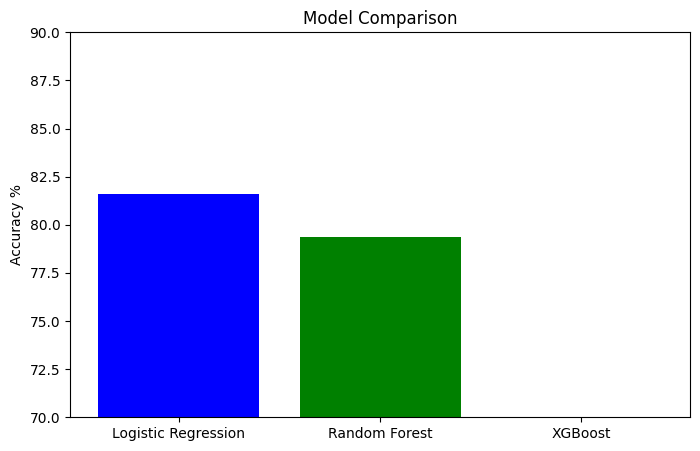

In [37]:
# Compare all 3 models together:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [81.6, 79.35, 0]  # we will fill XGBoost after you run it

plt.figure(figsize=(8,5))
plt.bar(models, scores, color=['blue', 'green', 'orange'])
plt.title('Model Comparison')
plt.ylabel('Accuracy %')
plt.ylim([70, 90])
plt.show()

In [38]:
print("✅ XGBoost Accuracy:",
      round(accuracy_score(y_test, xgb_pred) * 100, 2), "%")

✅ XGBoost Accuracy: 78.14 %


In [39]:
print("="*40)
print("   CHURN PROJECT - FINAL RESULTS")
print("="*40)
print("Best Model : Logistic Regression")
print("Accuracy   : 81.6%")
print("Total Data : 7043 customers")
print("Train Data : 5634 rows")
print("Test Data  : 1409 rows")
print("="*40)
print("✅ Project Complete!")

   CHURN PROJECT - FINAL RESULTS
Best Model : Logistic Regression
Accuracy   : 81.6%
Total Data : 7043 customers
Train Data : 5634 rows
Test Data  : 1409 rows
✅ Project Complete!


In [40]:
import pickle

# Save the model to a file
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the scaler too!
with open('churn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [41]:
# Load it back and test
with open('churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("✅ Model loaded successfully!")
print("Test accuracy:",
      round(accuracy_score(y_test, loaded_model.predict(X_test)) * 100, 2), "%")

✅ Model loaded successfully!
Test accuracy: 81.62 %


In [42]:
from google.colab import files

files.download('churn_model.pkl')
files.download('churn_scaler.pkl')

print("✅ Files downloaded to your computer!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded to your computer!


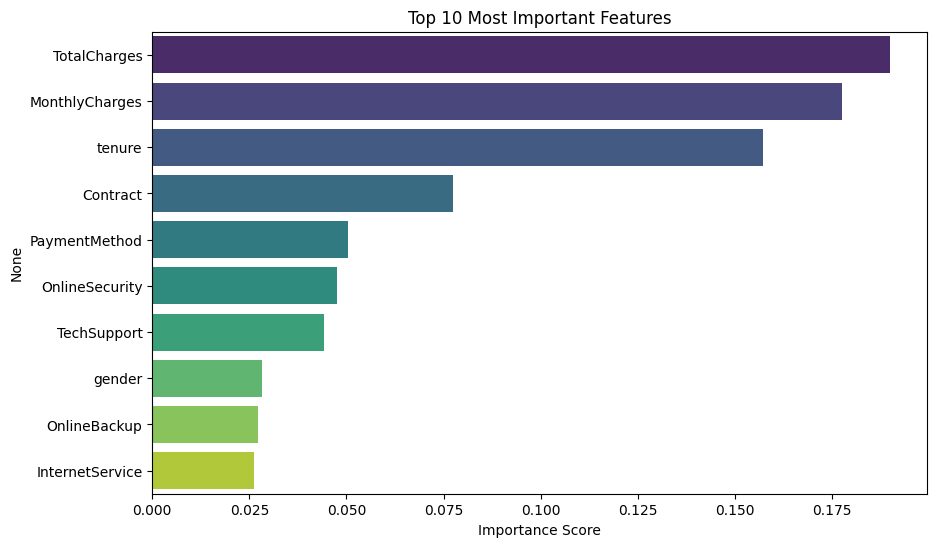

In [43]:
#Feature Importance Graph:
#This shows which factors matter most for churn prediction!
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance.values[:10],
            y=feature_importance.index[:10],
            palette='viridis')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.show()

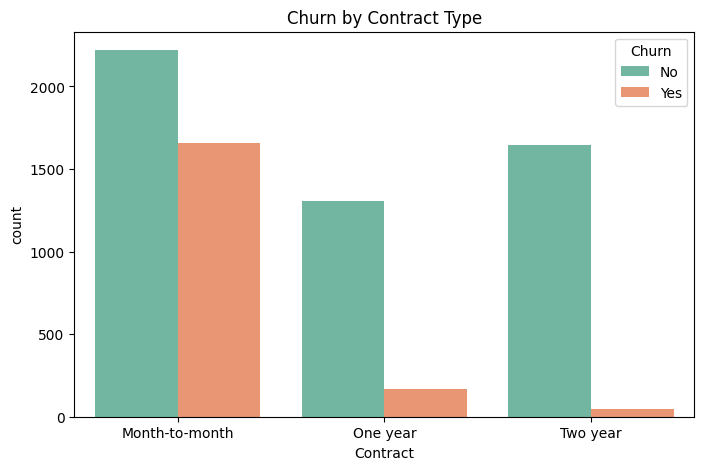

In [44]:
# Churn by Contract Type:
# Load original data again for visualization
df_viz = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df_viz, palette='Set2')
plt.title('Churn by Contract Type')
plt.show()

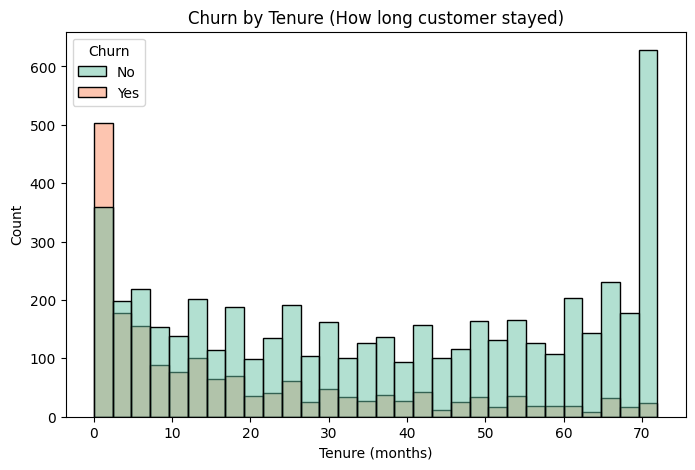

In [45]:
# Churn by Tenure:
plt.figure(figsize=(8,5))
sns.histplot(data=df_viz, x='tenure', hue='Churn',
             bins=30, palette='Set2')
plt.title('Churn by Tenure (How long customer stayed)')
plt.xlabel('Tenure (months)')
plt.show()

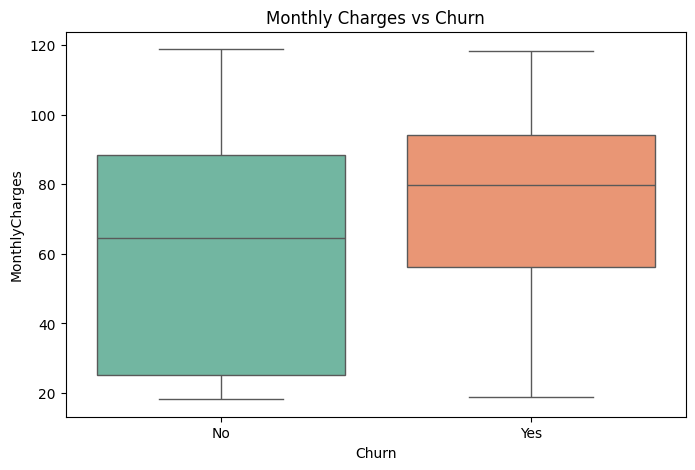

In [46]:
#Churn by Monthly Charges:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges',
            data=df_viz, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.show()

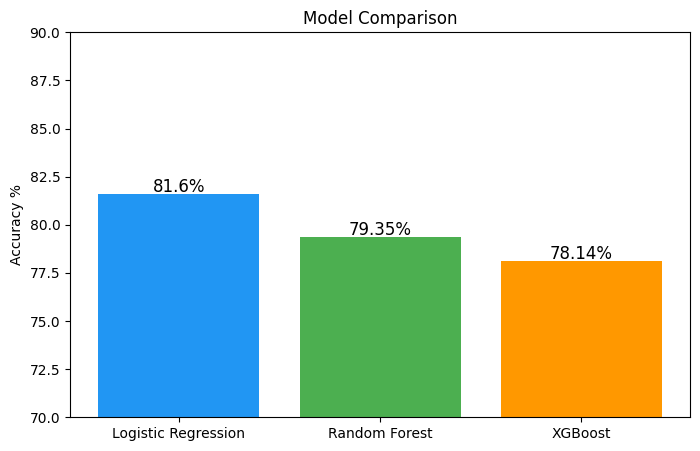

In [47]:
#All model accuracies graph:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [81.6, 79.35, 78.14]

plt.figure(figsize=(8,5))
bars = plt.bar(models, scores, color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Model Comparison')
plt.ylabel('Accuracy %')
plt.ylim([70, 90])

# Add numbers on top of bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{score}%', ha='center', fontsize=12)
plt.show()